**Задание 1 (EDA)**
1. Посмотрим информацию о датафрейме, проверим данные на пропуски и выбросы;
2. Посмотрим зависимость между признаками;
3. Проверим предложенные гипотезы, опишем выводы.


*Признаки:*
- client_id - идентификатор клиента
- education - уровень образования
- sex - пол заемщика
- age - возраст заемщика
- car - флаг наличия автомобиля
- car_type - флаг автомобиля иномарки
- decline_app_cnt - количество отказанных прошлых заявок
- good_work - флаг наличия “хорошей” работы
- bki_request_cnt - количество запросов в БКИ
- home_address - категоризатор домашнего адреса
- work_address - категоризатор рабочего адреса
- income - доход заемщика
- foreign_passport - наличие загранпаспорта
- sna - связь заемщика с клиентами банка
- first_time - давность наличия информации о заемщике
- score_bki - скоринговый балл по данным из БКИ
- region_rating - рейтинг региона
- app_date - дата подачи заявки
- default - флаг дефолта по кредиту

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


import warnings
warnings.filterwarnings('ignore')

In [2]:
#Выгрузка данных

url = 'https://raw.githubusercontent.com/yemtsovaanna-alt/WB_DS/main/data_.csv'

df = pd.read_csv(url)
print("Рзамер выборки:", df.shape)

Рзамер выборки: (73799, 19)


In [3]:
# Первые и последние 5 строк
display(df.head(5), df.tail(5))

# Типы данных
print(df.dtypes)

# Пропуски
print("Пропусков:\n", df.isna().sum())

#Явные дубликаты
print("Количество явных дубликатов:", df.duplicated().sum())

,client_id,app_date,education,sex,age,car,car_type,decline_app_cnt,good_work,score_bki,bki_request_cnt,region_rating,home_address,work_address,income,sna,first_time,foreign_passport,default
0,25905,01FEB2014,SCH,M,62,Y,Y,0,0,-2.008753,1,50,1,2,18000,4,1,N,0
1,63161,12MAR2014,SCH,F,59,N,N,0,0,-1.532276,3,50,2,3,19000,4,1,N,0
2,25887,01FEB2014,SCH,M,25,Y,N,2,0,-1.408142,1,80,1,2,30000,1,4,Y,0
3,16222,23JAN2014,SCH,F,53,N,N,0,0,-2.057471,2,50,2,3,10000,1,3,N,0
4,101655,18APR2014,GRD,M,48,N,N,0,1,-1.244723,1,60,2,3,30000,1,4,Y,0


,client_id,app_date,education,sex,age,car,car_type,decline_app_cnt,good_work,score_bki,bki_request_cnt,region_rating,home_address,work_address,income,sna,first_time,foreign_passport,default
73794,54887,04MAR2014,GRD,F,45,N,N,0,0,-1.792064,3,50,1,2,17000,4,4,N,0
73795,76821,24MAR2014,SCH,M,41,Y,Y,0,0,-2.058029,1,50,2,2,70000,1,4,N,0
73796,103695,22APR2014,SCH,M,31,N,N,0,0,-1.512635,4,80,2,3,45000,2,2,N,0
73797,861,04JAN2014,SCH,F,29,N,N,0,1,-1.479334,3,50,1,3,13000,2,3,N,1
73798,15796,23JAN2014,GRD,M,34,N,N,0,0,-1.764711,2,50,2,3,25000,1,3,N,0


client_id             int64
app_date             object
education            object
sex                  object
age                   int64
car                  object
car_type             object
decline_app_cnt       int64
good_work             int64
score_bki           float64
bki_request_cnt       int64
region_rating         int64
home_address          int64
work_address          int64
income                int64
sna                   int64
first_time            int64
foreign_passport     object
default               int64
dtype: object
Пропусков:
 client_id             0
app_date              0
education           307
sex                   0
age                   0
car                   0
car_type              0
decline_app_cnt       0
good_work             0
score_bki             0
bki_request_cnt       0
region_rating         0
home_address          0
work_address          0
income                0
sna                   0
first_time            0
foreign_passport      0
default   

In [4]:
# Признак education
df['education'].value_counts(dropna=False)

# если в дальнейшем планируется на данном датасета обучить логистическую регрессию, то можно пропуски заполнить модой,
# можно также попробовать обучить модель предсказывать пропуски

education
SCH    38860
GRD    23365
UGR     9816
PGR     1257
NaN      307
ACD      194
Name: count, dtype: int64

In [5]:
# Тип данных app_date с object на datetime
df['app_date'] = pd.to_datetime(df['app_date'])

# Бинарные признаки из object в bool
df['car'] = df['car'].map({'Y': True, 'N': False})
df['car_type'] = df['car_type'].map({'Y': True, 'N': False})
df['foreign_passport'] = df['foreign_passport'].map({'N': False, 'Y': True})
df['good_work'] = df['good_work'].astype(bool)
df['default'] = df['default'].astype(bool)  # 1 → True, 0 → False


In [6]:
# Косметическая преобработка готова. Теперь статистики по признакам.

# Количественные признаки
num_cols = [
    'age',
    'decline_app_cnt',
    'bki_request_cnt',
    'income',
    'score_bki'
]
print(df[num_cols].describe())

# Качественные признаки
cat_cols = [
    'education',
    'sex',
    'car',
    'car_type',
    'good_work',
    'home_address',
    'work_address',
    'foreign_passport',
    'sna',
    'first_time',
    'region_rating',
    'default'
]

def describe_categorical(df, name):

    cat_df = df.select_dtypes(include=['object', 'category', 'bool'])

    print(f"\n{'='*50}")
    print(f"Категориальные столбцы в {name}: {list(cat_df.columns)}")
    print('='*50)

    if cat_df.shape[1] > 0:

        print(cat_df.describe().T.to_string())

        print(f"\nЧисло уникальных категорий в {name}:")
        print(cat_df.nunique().sort_values(ascending=False).to_string())

    else:
        print(f"В {name} нет категориальных столбцов")


describe_categorical(df, 'df')




                age  decline_app_cnt  bki_request_cnt          income  \
count  73799.000000     73799.000000     73799.000000    73799.000000   
mean      39.280641         0.275749         2.000339    41099.775417   
std       11.520378         0.804272         2.252073    46166.322400   
min       21.000000         0.000000         0.000000     1000.000000   
25%       30.000000         0.000000         0.000000    20000.000000   
50%       37.000000         0.000000         1.000000    30000.000000   
75%       48.000000         0.000000         3.000000    48000.000000   
max       72.000000        33.000000        53.000000  1000000.000000   

          score_bki  
count  73799.000000  
mean      -1.904724  
std        0.498231  
min       -3.624586  
25%       -2.259534  
50%       -1.920823  
75%       -1.569831  
max        0.199773  

Категориальные столбцы в df: ['education', 'sex', 'car', 'car_type', 'good_work', 'foreign_passport', 'default']
                  count unique

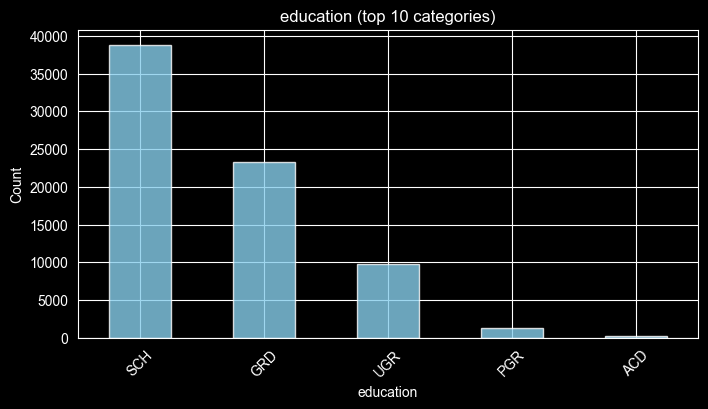

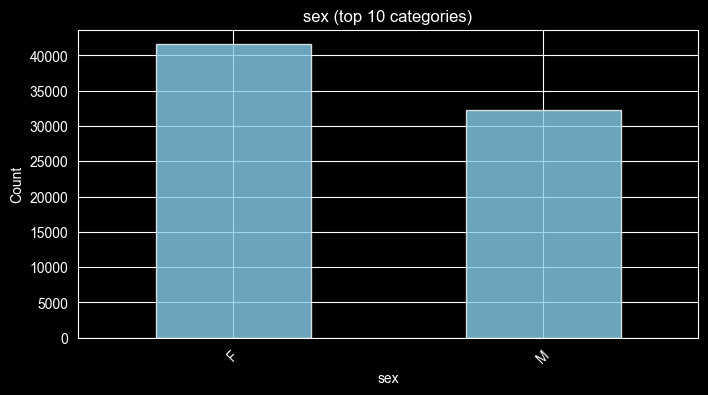

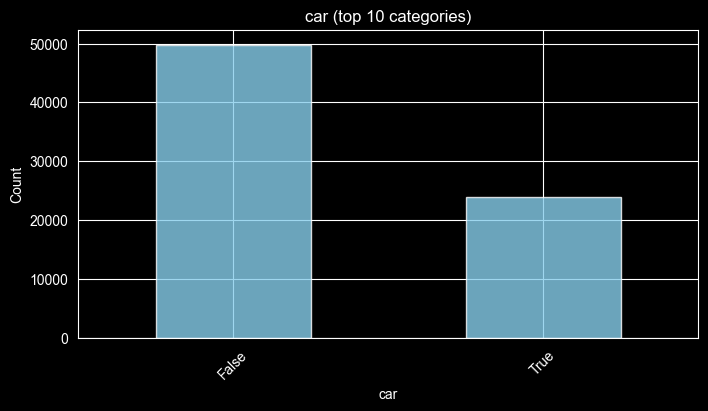

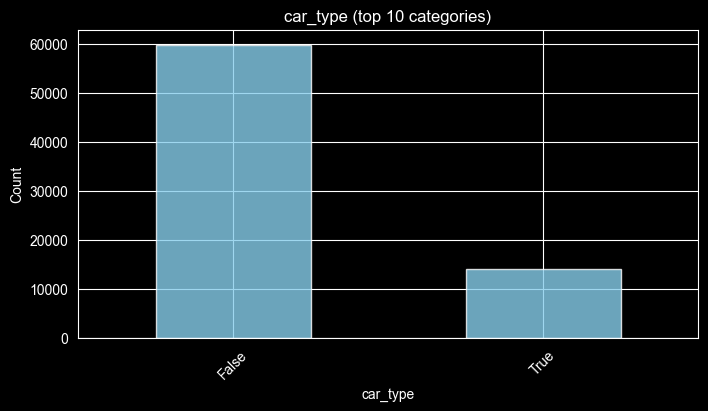

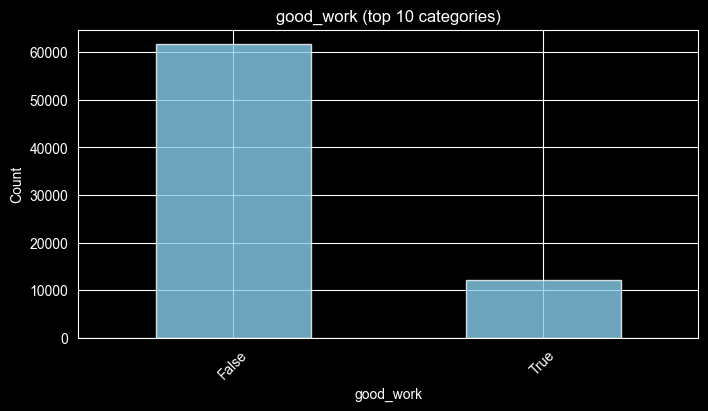

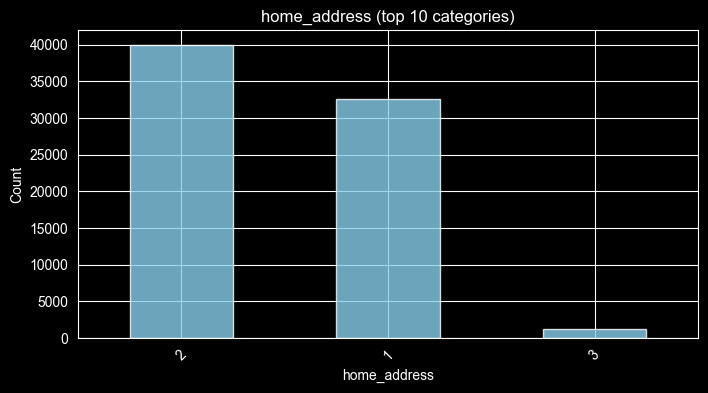

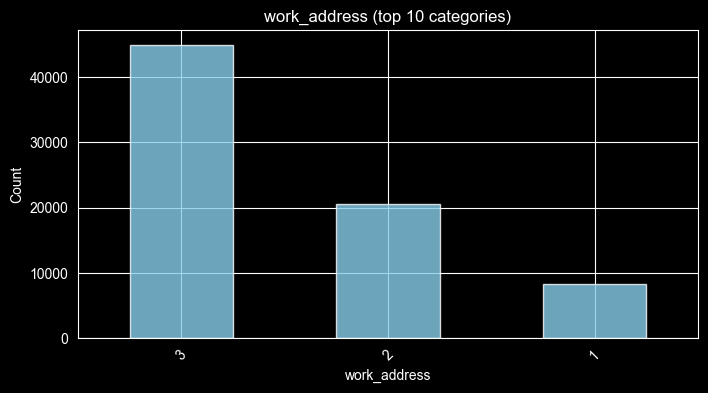

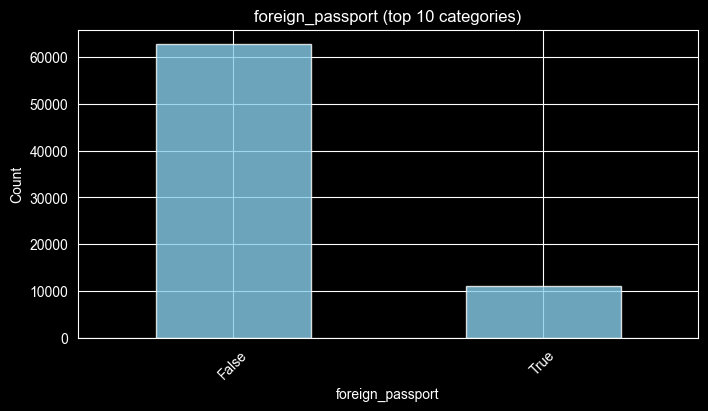

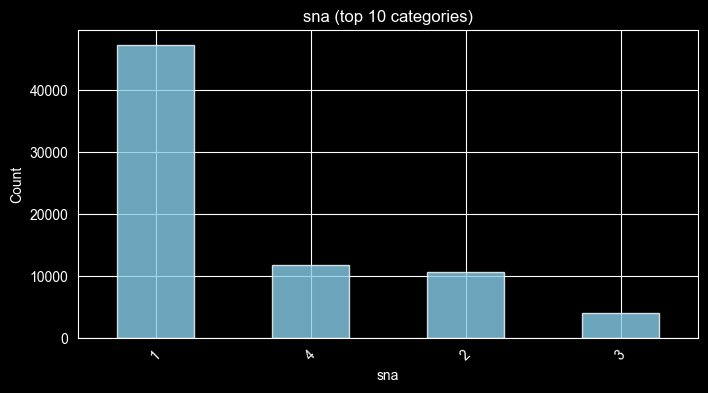

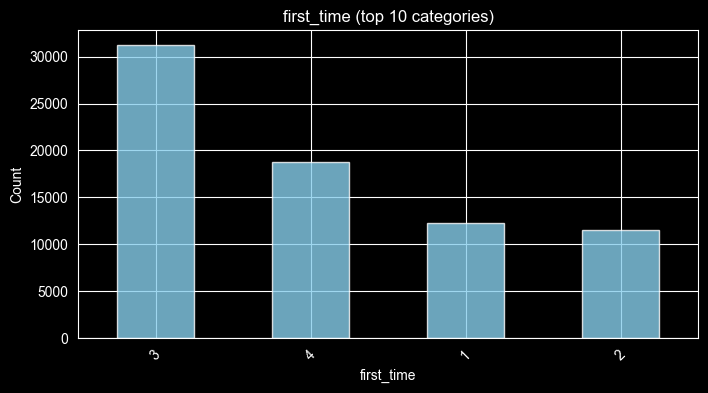

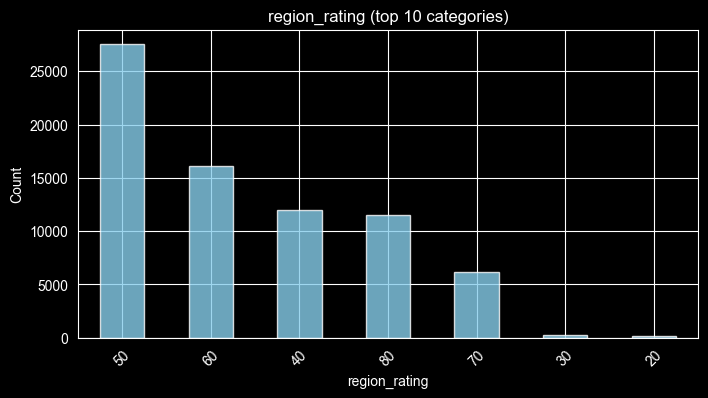

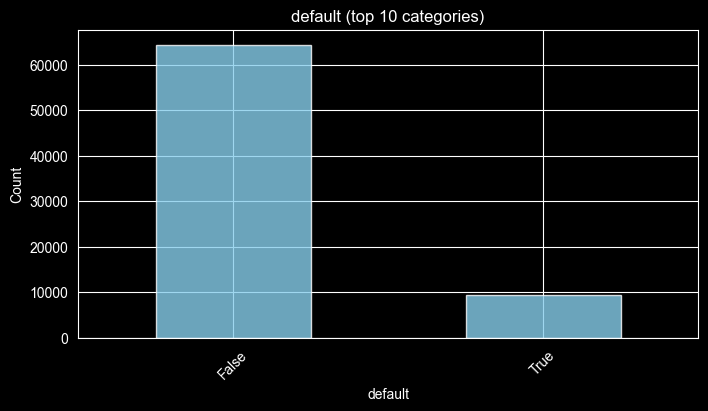

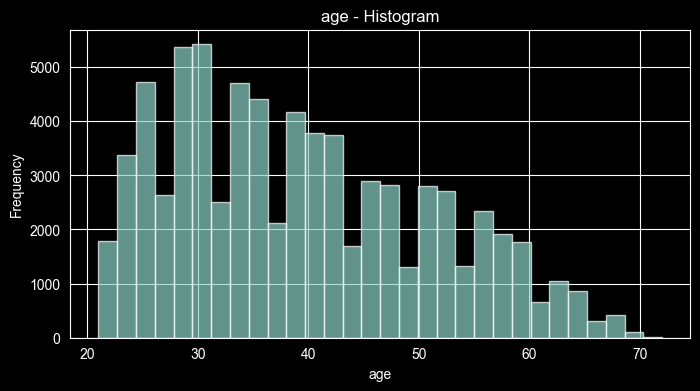

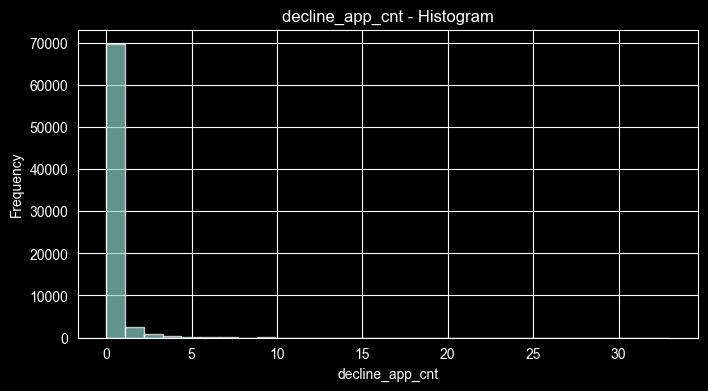

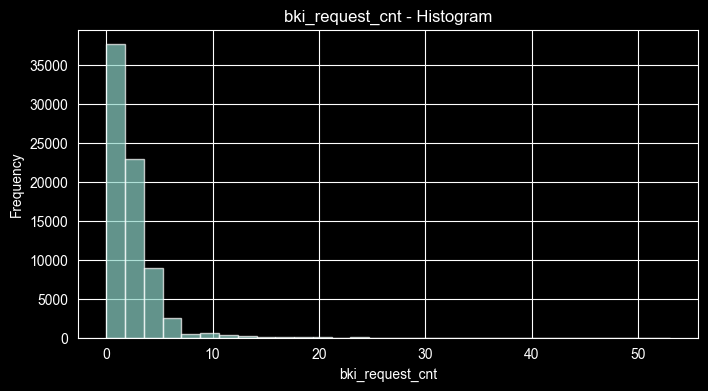

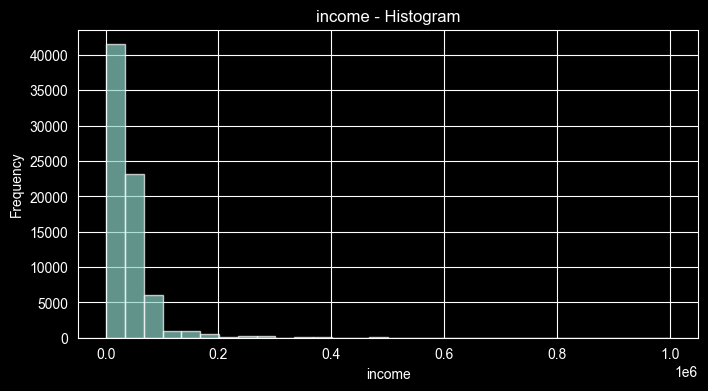

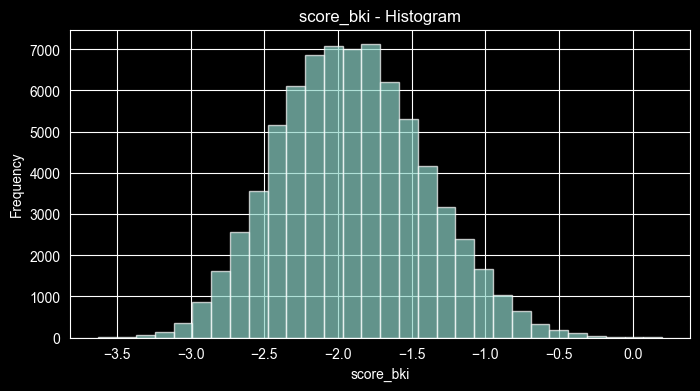

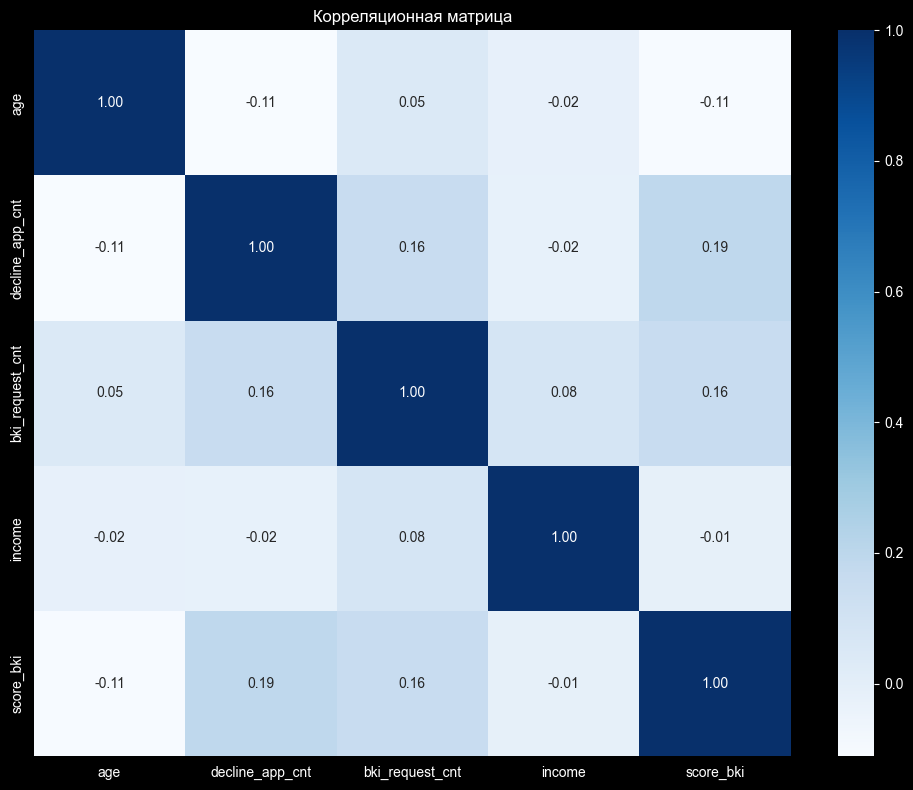

In [7]:
# Визуализация

# Визуализация категориальных признаков
for col in cat_cols:

    plt.figure(figsize=(8, 4))

    df[col].value_counts().head(10).plot(
        kind='bar',
        color='skyblue',
        alpha=0.8
    )

    plt.title(f'{col} (top 10 categories)')
    plt.xticks(rotation=45)
    plt.ylabel('Count')

    plt.show()


# Визуализация количественных признаков
for col in num_cols:

    plt.figure(figsize=(8, 4))

    plt.hist(df[col], bins=30, alpha=0.7)

    plt.title(f'{col} - Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()


# Корреляционная матрица только для количественных признаков

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[num_cols].corr(),
    cmap='Blues',
    annot=True,
    fmt='.2f'
)

plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()


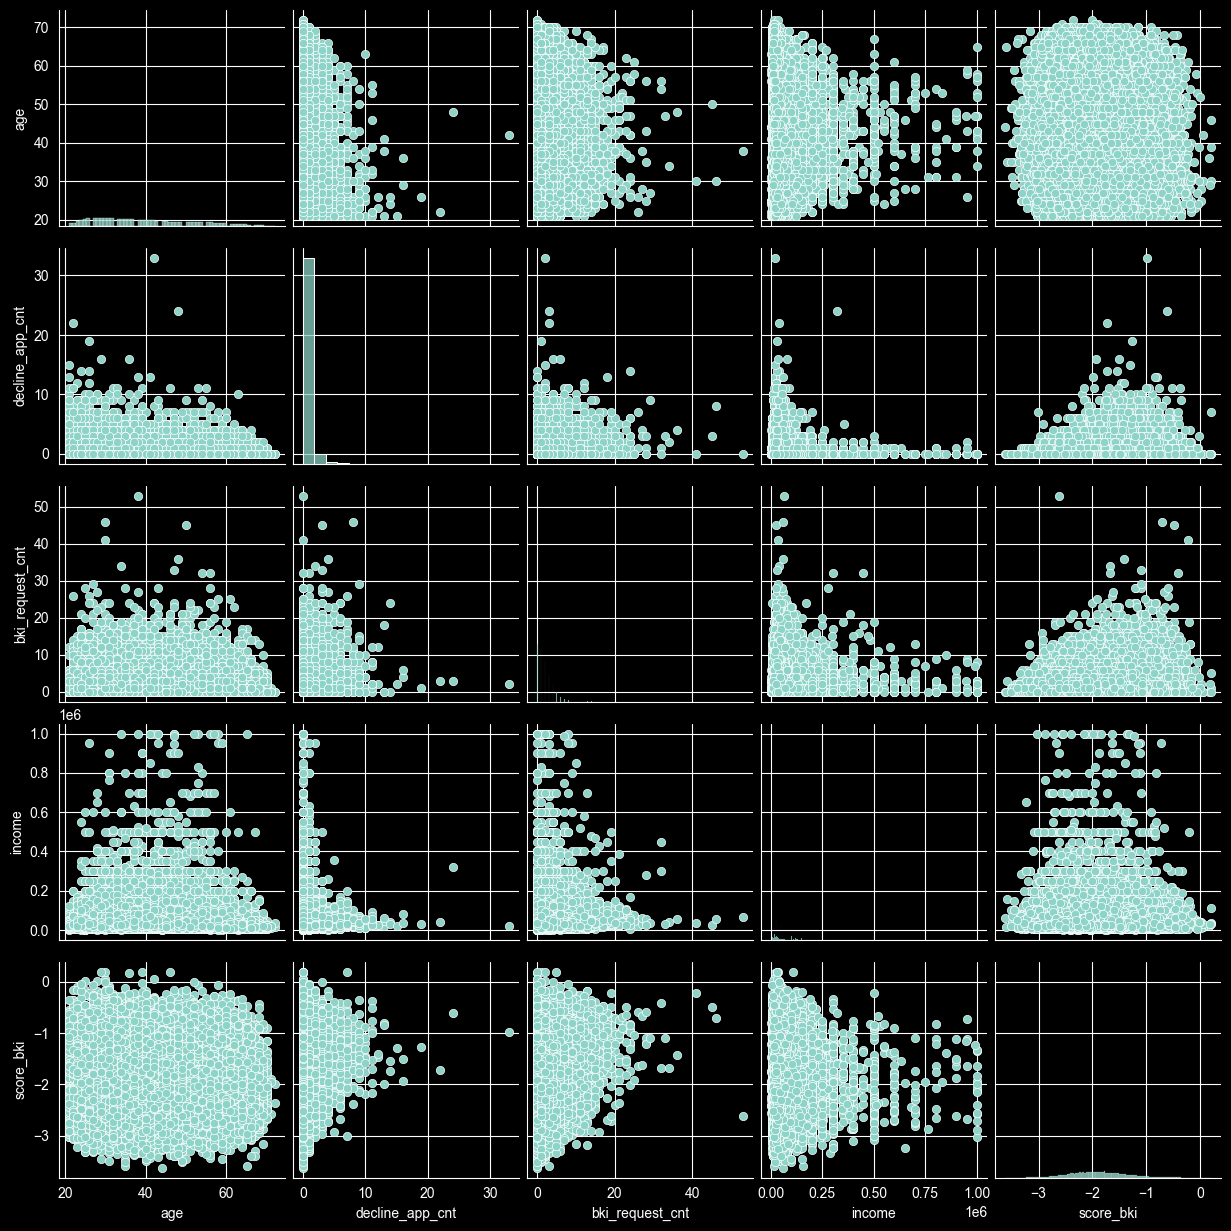

Корреляция Пирсона:
                      age  decline_app_cnt  bki_request_cnt    income  \
age              1.000000        -0.111175         0.046265 -0.018900   
decline_app_cnt -0.111175         1.000000         0.155894 -0.021687   
bki_request_cnt  0.046265         0.155894         1.000000  0.082983   
income          -0.018900        -0.021687         0.082983  1.000000   
score_bki       -0.106275         0.189987         0.156257 -0.012639   

                 score_bki  
age              -0.106275  
decline_app_cnt   0.189987  
bki_request_cnt   0.156257  
income           -0.012639  
score_bki         1.000000  


In [8]:
# Попарные распределения числовых признаков
# и корреляция Пирсона

sns.pairplot(
    df[num_cols],
    kind='scatter',
    diag_kind='hist'
)

plt.show()


# Корреляция Пирсона
pearson_corr = df[num_cols].corr(method='pearson')

print('Корреляция Пирсона:')
print(pearson_corr)

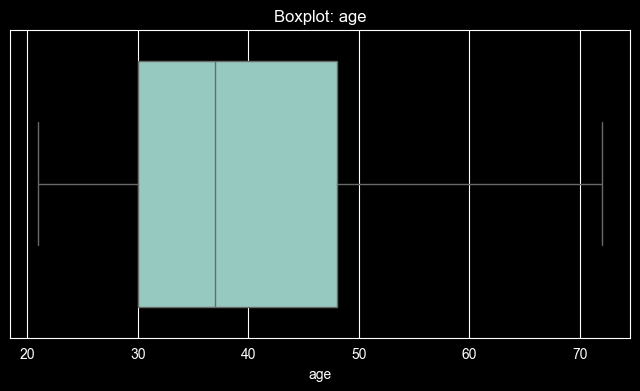

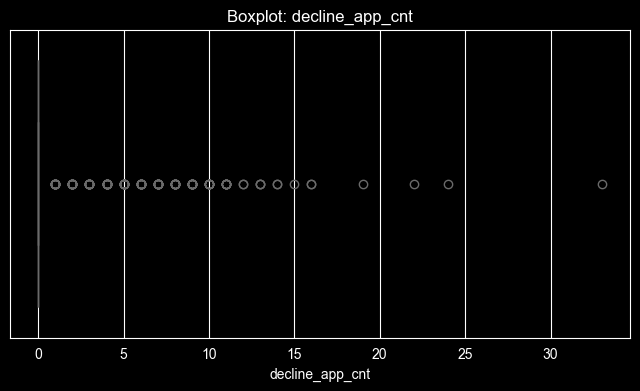

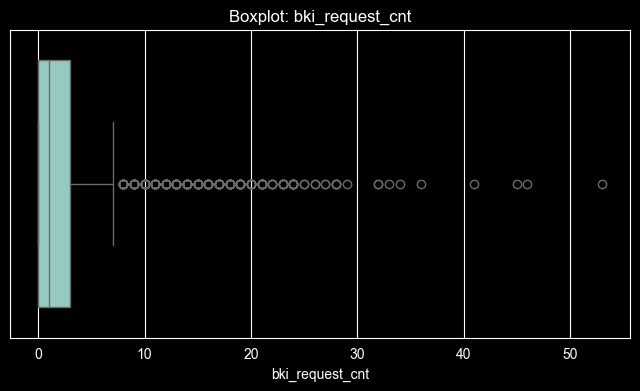

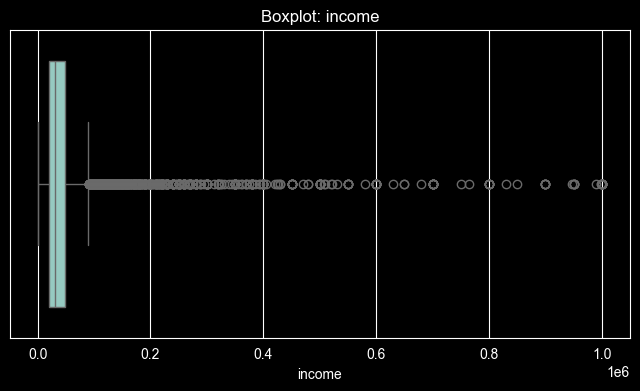

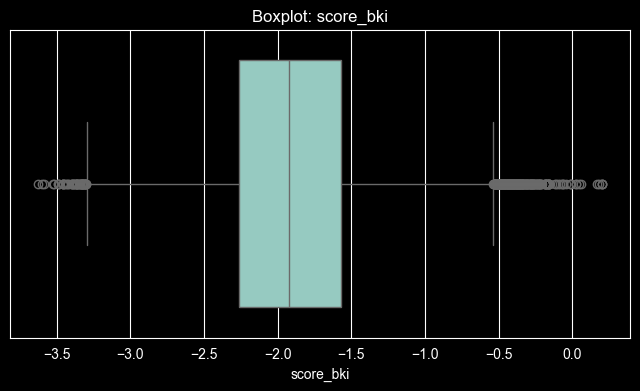

In [9]:
# Ящик с усами (boxplot) для количественных признаков

for col in num_cols:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot: {col}')

    plt.show()

# Проверка гипотез

Гипотезы:
1. Возраст "хороших" заемщиков больше, по сравнению с "плохими" (распределения возраста в зависимости от флага дефолта смещено в большую сторону при default=0), возрастные более платежеспособные;
2. Уровень образования зависит от возраста, что влияет и на возврат кредита, также люди с высшим образованием чаще являются "хорошими" заемщиками;
3. При good_work = 0 увеличивается риск невозврата кредита (флаг дефолта);
4. Доход "хороших" заемщиков больше, по сравнению с "плохими" (распределения дохода в зависимости от флага дефолта смещено в большую сторону при default=0);
5. score_bki напрямую взаимосвязан с default, чем он меньше, тем выше вероятность клиента выплатить кредит банку;
6. Наличие авто влияет на вероятность возврата кредита;
7. Рейтинг региона влияет на размер зарплаты, что также может повлиять на возврат кредита.

Статистики по возрасту:
  default=0 (хорошие): среднее=39.4, медиана=38.0
  default=1 (плохие):  среднее=38.5, медиана=36.0


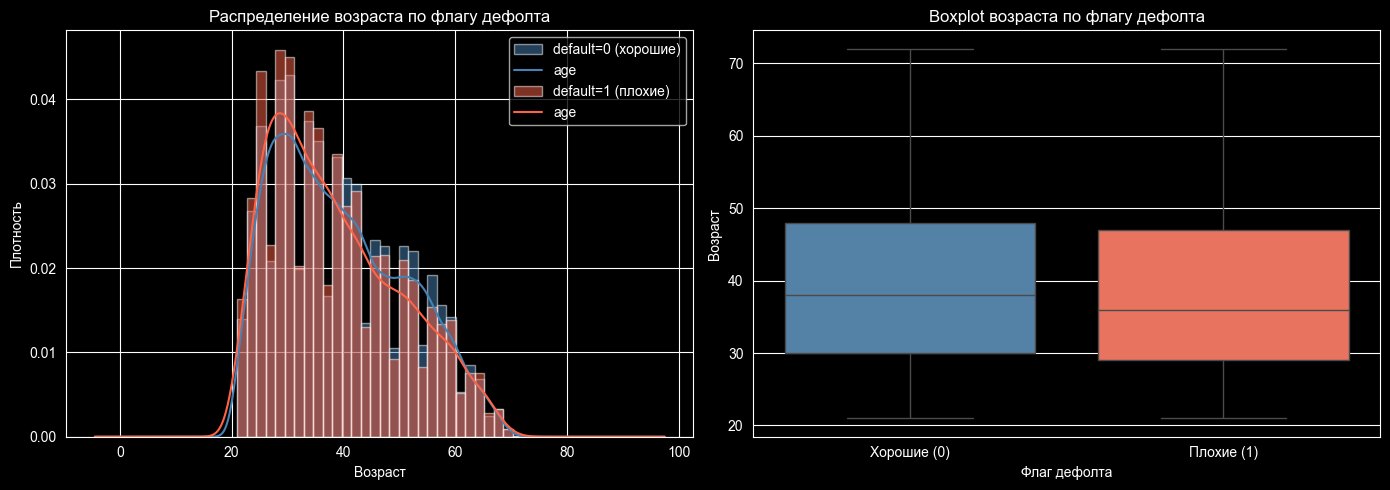


Критерий Манна-Уитни (H1: возраст хороших > плохих):
  Статистика U = 315897284, p-value = 1.8824680397e-13
  p-value < 0.01 → отвергаем H0. Гипотеза ПОДТВЕРЖДАЕТСЯ: возраст хороших заемщиков статистически значимо больше.


In [10]:
#1. Возраст "хороших" заемщиков больше, по сравнению с "плохими"
# (распределения возраста в зависимости от флага дефолта смещено в большую сторону при default=0)

age_good = df[df['default'] == False]['age']  # хорошие заёмщики (нет дефолта)
age_bad  = df[df['default'] == True]['age']   # плохие заёмщики (дефолт)

# Описательные статистики
print("Статистики по возрасту:")
print(f"  default=0 (хорошие): среднее={age_good.mean():.1f}, медиана={age_good.median():.1f}")
print(f"  default=1 (плохие):  среднее={age_bad.mean():.1f}, медиана={age_bad.median():.1f}")

# --- Визуализация ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE-график
for label, data, color in [('default=0 (хорошие)', age_good, 'steelblue'),
                             ('default=1 (плохие)',  age_bad,  'tomato')]:
    axes[0].hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
    data.plot.kde(ax=axes[0], color=color)

axes[0].set_title('Распределение возраста по флагу дефолта')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Плотность')
axes[0].legend()

# Boxplot
df_plot = df[['age', 'default']].copy()
df_plot['default_label'] = df_plot['default'].map({False: 'Хорошие (0)', True: 'Плохие (1)'})
sns.boxplot(data=df_plot, x='default_label', y='age', palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Boxplot возраста по флагу дефолта')
axes[1].set_xlabel('Флаг дефолта')
axes[1].set_ylabel('Возраст')

plt.tight_layout()
plt.show()

# Статистический тест (критерий Манна-Уитни)
stat, p_value = stats.mannwhitneyu(age_good, age_bad, alternative='greater')
print(f"\nКритерий Манна-Уитни (H1: возраст хороших > плохих):")
print(f"  Статистика U = {stat:.0f}, p-value = {p_value:.10e}")

alpha = 0.01
if p_value < alpha:
    print(f"  p-value < {alpha} → отвергаем H0. Гипотеза ПОДТВЕРЖДАЕТСЯ: возраст хороших заемщиков статистически значимо больше.")
else:
    print(f"  p-value >= {alpha} → не отвергаем H0. Гипотеза НЕ подтверждается.")


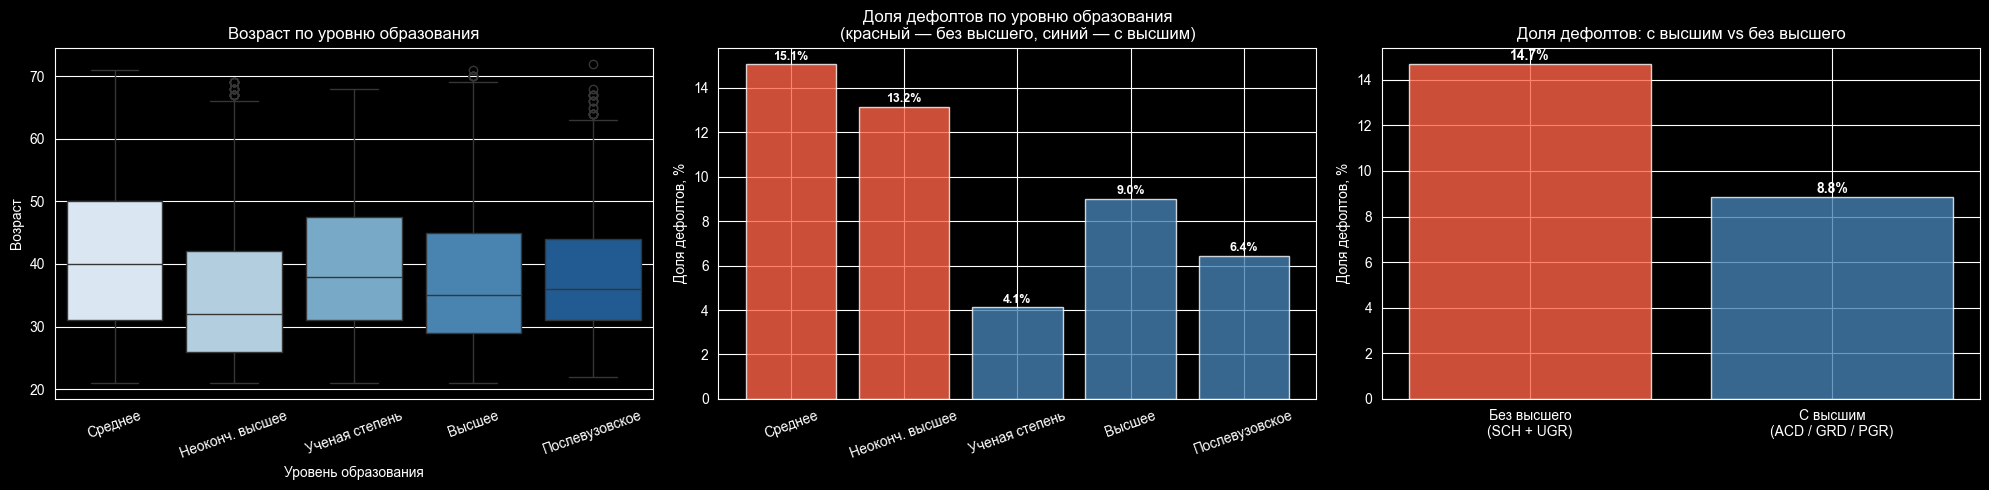

Средний возраст по уровню образования:
             mean  median
edu_ordered              
SCH          41.1    40.0
UGR          34.9    32.0
ACD          40.1    38.0
GRD          38.1    35.0
PGR          38.3    36.0

Доля дефолтов: с высшим vs без высшего:
                            Всего  Дефолтов  Доля дефолтов, %
Без высшего (SCH + UGR)     48676      7143             14.67
С высшим (ACD / GRD / PGR)  24816      2194              8.84

Краскела-Уоллис (возраст ~ образование, 5 групп):
  H = 2925.07, p-value = 0.0000000000e+00
  Effect size (ε²) = 0.0397 — эффект средний
  → Возраст статистически значимо различается между группами образования.

Хи-квадрат (дефолт ~ образование, 5 групп):
  χ² = 541.03, df = 4, p-value = 8.9449287925e-116
  Cramér's V = 0.0858 — эффект незначительный

Хи-квадрат (дефолт ~ с высшим/без высшего, бинарно):
  χ² = 503.80, df = 1, p-value = 0.0000
  Cramér's V = 0.0828 — эффект незначительный
  → У людей с высшим образованием дефолт реже (8.8% vs 14.

In [11]:
#2. Уровень образования зависит от возраста, что влияет и на возврат кредита, также
#   люди с высшим образованием чаще являются "хорошими" заемщиками
#
#   Без высшего: SCH (среднее), UGR (неоконченное высшее)
#   С высшим:    ACD (ученая степень), GRD (высшее), PGR (послевузовское)

df_edu = df.dropna(subset=['education'])

# Порядок уровней образования (от низшего к высшему)
edu_order = ['SCH', 'UGR', 'ACD', 'GRD', 'PGR']
edu_labels = {'SCH': 'Среднее', 'UGR': 'Неоконч. высшее', 'ACD': 'Ученая степень', 'GRD': 'Высшее', 'PGR': 'Послевузовское'}

df_edu['edu_ordered'] = pd.Categorical(df_edu['education'], categories=edu_order, ordered=True)
df_edu = df_edu.sort_values('edu_ordered')

# Флаг: SCH и UGR → без высшего; ACD, GRD, PGR → с высшим
df_edu['higher_edu'] = df_edu['education'].isin(['ACD', 'GRD', 'PGR'])

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Возраст по уровню образования
sns.boxplot(data=df_edu, x='edu_ordered', y='age',
            order=edu_order, palette='Blues', ax=axes[0])
axes[0].set_title('Возраст по уровню образования')
axes[0].set_xlabel('Уровень образования')
axes[0].set_ylabel('Возраст')
axes[0].set_xticklabels([edu_labels[e] for e in edu_order], rotation=20)

# 2) Доля дефолтов по уровню образования (детально)
default_rate = df_edu.groupby('edu_ordered', observed=True)['default'].mean().reset_index()
default_rate.columns = ['education', 'default_rate']
bars = axes[1].bar(range(len(default_rate)), default_rate['default_rate'] * 100,
                   color=['tomato', 'tomato', 'steelblue', 'steelblue', 'steelblue'],
                   alpha=0.8)
axes[1].set_xticks(range(len(default_rate)))
axes[1].set_xticklabels([edu_labels[e] for e in default_rate['education']], rotation=20)
axes[1].set_title('Доля дефолтов по уровню образования\n(красный — без высшего, синий — с высшим)')
axes[1].set_ylabel('Доля дефолтов, %')
for bar, v in zip(bars, default_rate['default_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.2, f'{v:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# 3) Доля дефолтов: с высшим vs без высшего
rates_higher = df_edu.groupby('higher_edu')['default'].mean() * 100
labels_higher = ['Без высшего\n(SCH + UGR)', 'С высшим\n(ACD / GRD / PGR)']
bars2 = axes[2].bar(labels_higher, rates_higher.values,
                    color=['tomato', 'steelblue'], alpha=0.8)
axes[2].set_title('Доля дефолтов: с высшим vs без высшего')
axes[2].set_ylabel('Доля дефолтов, %')
for bar, v in zip(bars2, rates_higher.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, v + 0.2, f'{v:.1f}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Описательные статистики
print("Средний возраст по уровню образования:")
print(df_edu.groupby('edu_ordered', observed=True)['age'].agg(['mean', 'median']).round(1).to_string())

print("\nДоля дефолтов: с высшим vs без высшего:")
tbl = df_edu.groupby('higher_edu')['default'].agg(['mean', 'sum', 'count'])
tbl.index = ['Без высшего (SCH + UGR)', 'С высшим (ACD / GRD / PGR)']
tbl.columns = ['Доля дефолтов', 'Дефолтов', 'Всего']
tbl['Доля дефолтов, %'] = (tbl['Доля дефолтов'] * 100).round(2)
print(tbl[['Всего', 'Дефолтов', 'Доля дефолтов, %']])

#  Тест 1: Краскела-Уоллис — возраст ~ образование (5 групп)
groups_age = [df_edu[df_edu['education'] == edu]['age'].values for edu in edu_order]
n_total = sum(len(g) for g in groups_age)
k = len(groups_age)
stat_kw, p_kw = stats.kruskal(*groups_age)

epsilon_sq = (stat_kw - k + 1) / (n_total - k)

def interpret_epsilon_sq(e):
    if e < 0.01:   return "незначительный"
    elif e < 0.06: return "средний"
    elif e < 0.14: return "умеренно большой"
    else:          return "большой"

print(f"\nКраскела-Уоллис (возраст ~ образование, 5 групп):")
print(f"  H = {stat_kw:.2f}, p-value = {p_kw:.10e}")
print(f"  Effect size (ε²) = {epsilon_sq:.4f} — эффект {interpret_epsilon_sq(epsilon_sq)}")
if p_kw < 0.01:
    print("  → Возраст статистически значимо различается между группами образования.")
else:
    print("  → Значимых различий возраста между группами образования не обнаружено.")

# Тест 2: Хи-квадрат — дефолт ~ образование (5 групп, Cramér's V)
contingency = pd.crosstab(df_edu['education'], df_edu['default'])
chi2, p_chi2, dof, _ = stats.chi2_contingency(contingency)
n = contingency.values.sum()
r, c = contingency.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

def interpret_cramers_v(v, min_dim):
    thresholds = {1: (0.10, 0.30), 2: (0.07, 0.21), 3: (0.06, 0.17), 4: (0.05, 0.15)}
    small, large = thresholds.get(min_dim - 1, (0.05, 0.15))
    if v < small:   return "незначительный"
    elif v < large: return "средний"
    else:           return "большой"

print(f"\nХи-квадрат (дефолт ~ образование, 5 групп):")
print(f"  χ² = {chi2:.2f}, df = {dof}, p-value = {p_chi2:.10e}")
print(f"  Cramér's V = {cramers_v:.4f} — эффект {interpret_cramers_v(cramers_v, min(r, c))}")

# ── Тест 3: Хи-квадрат — с высшим vs без высшего (бинарно, Cramér's V) ───────
contingency2 = pd.crosstab(df_edu['higher_edu'], df_edu['default'])
chi2_b, p_b, dof_b, _ = stats.chi2_contingency(contingency2)
n_b = contingency2.values.sum()
cramers_v_b = np.sqrt(chi2_b / (n_b * (min(contingency2.shape) - 1)))

print(f"\nХи-квадрат (дефолт ~ с высшим/без высшего, бинарно):")
print(f"  χ² = {chi2_b:.2f}, df = {dof_b}, p-value = {p_b:.4f}")
print(f"  Cramér's V = {cramers_v_b:.4f} — эффект {interpret_cramers_v(cramers_v_b, min(contingency2.shape))}")
if p_b < 0.01:
    r0 = df_edu[df_edu['higher_edu'] == False]['default'].mean() * 100
    r1 = df_edu[df_edu['higher_edu'] == True]['default'].mean() * 100
    if r1 < r0:
        print(f"  → У людей с высшим образованием дефолт реже ({r1:.1f}% vs {r0:.1f}%). Гипотеза ПОДТВЕРЖДАЕТСЯ данными.")
    else:
        print(f"  → У людей с высшим образованием дефолт НЕ реже ({r1:.1f}% vs {r0:.1f}%). Гипотеза НЕ подтверждается данными.")
else:
    print("  → Значимой разницы не обнаружено. Гипотеза НЕ подтверждается.")


             Всего  Кол-во дефолтов  Доля дефолтов, %
good_work                                            
good_work=0  61630             8222             13.34
good_work=1  12169             1150              9.45


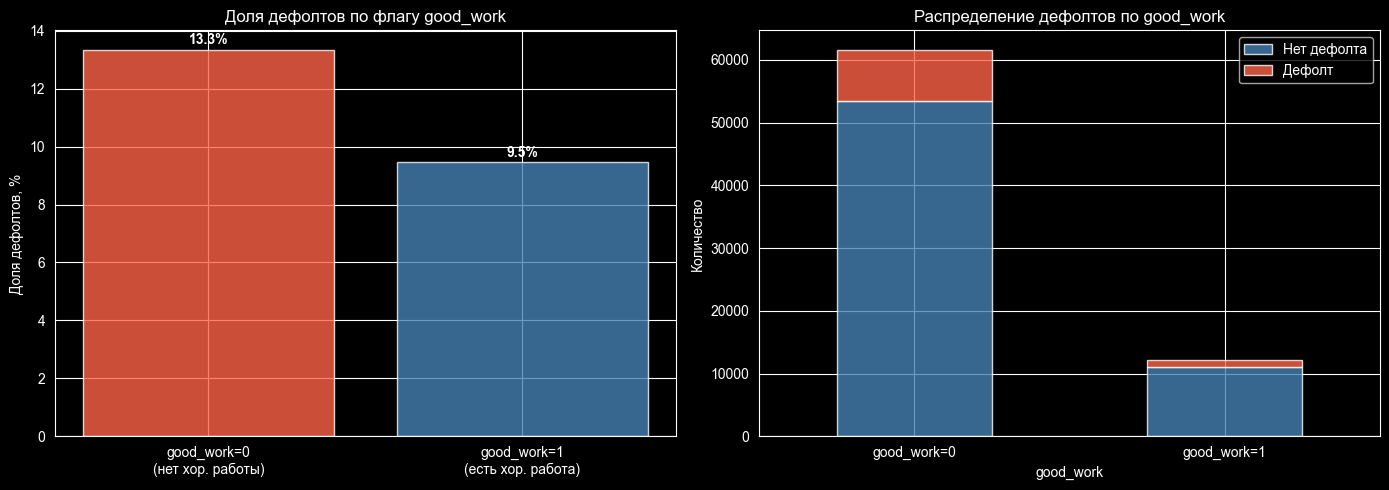


Хи-квадрат (дефолт ~ good_work):
  χ² = 138.40, df = 1, p-value = 0.0000
  → При good_work=0 доля дефолтов выше (13.3% vs 9.5%). Гипотеза ПОДТВЕРЖДАЕТСЯ данными.


In [12]:
#3. При good_work = 0 увеличивается риск невозврата кредита (флаг дефолта)

# Описательные статистики
default_by_work = df.groupby('good_work')['default'].agg(['mean', 'sum', 'count'])
default_by_work.index = default_by_work.index.map({False: 'good_work=0', True: 'good_work=1'})
default_by_work.columns = ['Доля дефолтов', 'Кол-во дефолтов', 'Всего']
default_by_work['Доля дефолтов, %'] = (default_by_work['Доля дефолтов'] * 100).round(2)
print(default_by_work[['Всего', 'Кол-во дефолтов', 'Доля дефолтов, %']])

#  Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбчатая диаграмма — доля дефолтов
labels = ['good_work=0\n(нет хор. работы)', 'good_work=1\n(есть хор. работа)']
rates = [
    df[df['good_work'] == False]['default'].mean() * 100,
    df[df['good_work'] == True]['default'].mean() * 100,
]
axes[0].bar(labels, rates, color=['tomato', 'steelblue'], alpha=0.8)
axes[0].set_title('Доля дефолтов по флагу good_work')
axes[0].set_ylabel('Доля дефолтов, %')
for i, v in enumerate(rates):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# Stacked bar — абсолютное распределение
ct = pd.crosstab(df['good_work'], df['default'])
ct.index = ['good_work=0', 'good_work=1']
ct.columns = ['Нет дефолта', 'Дефолт']
ct.plot(kind='bar', stacked=True, color=['steelblue', 'tomato'], alpha=0.8, ax=axes[1])
axes[1].set_title('Распределение дефолтов по good_work')
axes[1].set_xlabel('good_work')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Статистический тест: хи-квадрат
contingency = pd.crosstab(df['good_work'], df['default'])
chi2, p_chi2, dof, _ = stats.chi2_contingency(contingency)
print(f"\nХи-квадрат (дефолт ~ good_work):")
print(f"  χ² = {chi2:.2f}, df = {dof}, p-value = {p_chi2:.4f}")
if p_chi2 < 0.01:
    no_good = df[df['good_work'] == False]['default'].mean()
    yes_good = df[df['good_work'] == True]['default'].mean()
    if no_good > yes_good:
        print(f"  → При good_work=0 доля дефолтов выше ({no_good*100:.1f}% vs {yes_good*100:.1f}%). Гипотеза ПОДТВЕРЖДАЕТСЯ данными.")
    else:
        print(f"  → При good_work=0 доля дефолтов НЕ выше ({no_good*100:.1f}% vs {yes_good*100:.1f}%). Гипотеза НЕ подтверждается данными.")
else:
    print("  → Значимой связи между good_work и дефолтом не обнаружено. Гипотеза НЕ подтверждается данными.")


Статистики по доходу:
  default=0 (хорошие): среднее=41800, медиана=30000
  default=1 (плохие):  среднее=36288, медиана=28000


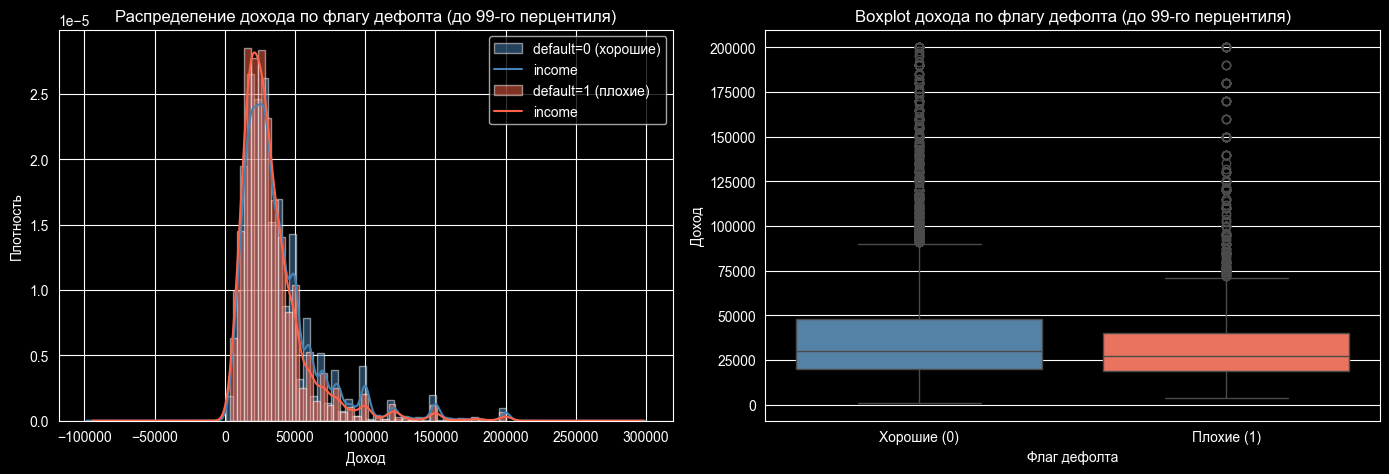


Критерий Манна-Уитни (H1: доход хороших > плохих):
  Статистика U = 332668288, p-value = 0.0000
  p-value < 0.01 → отвергаем H0. Гипотеза ПОДТВЕРЖДАЕТСЯ: доход хороших заемщиков статистически значимо больше.


In [13]:
#4. Доход "хороших" заемщиков больше, по сравнению с "плохими"
# (распределения дохода в зависимости от флага дефолта смещено в большую сторону при default=0)

income_good = df[df['default'] == False]['income']
income_bad  = df[df['default'] == True]['income']

# Описательные статистики
print("Статистики по доходу:")
print(f"  default=0 (хорошие): среднее={income_good.mean():.0f}, медиана={income_good.median():.0f}")
print(f"  default=1 (плохие):  среднее={income_bad.mean():.0f}, медиана={income_bad.median():.0f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE + гистограмма (обрезаем выбросы до 99-го перцентиля для читаемости)
cap = df['income'].quantile(0.99)
for label, data, color in [('default=0 (хорошие)', income_good, 'steelblue'),
                             ('default=1 (плохие)',  income_bad,  'tomato')]:
    clipped = data[data <= cap]
    axes[0].hist(clipped, bins=40, alpha=0.5, color=color, label=label, density=True)
    clipped.plot.kde(ax=axes[0], color=color)

axes[0].set_title('Распределение дохода по флагу дефолта (до 99-го перцентиля)')
axes[0].set_xlabel('Доход')
axes[0].set_ylabel('Плотность')
axes[0].legend()

# Boxplot
df_plot = df[['income', 'default']].copy()
df_plot['default_label'] = df_plot['default'].map({False: 'Хорошие (0)', True: 'Плохие (1)'})
sns.boxplot(data=df_plot[df_plot['income'] <= cap],
            x='default_label', y='income',
            palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Boxplot дохода по флагу дефолта (до 99-го перцентиля)')
axes[1].set_xlabel('Флаг дефолта')
axes[1].set_ylabel('Доход')

plt.tight_layout()
plt.show()

# Статистический тест (критерий Манна-Уитни)
stat, p_value = stats.mannwhitneyu(income_good, income_bad, alternative='greater')
print(f"\nКритерий Манна-Уитни (H1: доход хороших > плохих):")
print(f"  Статистика U = {stat:.0f}, p-value = {p_value:.4f}")

alpha = 0.01
if p_value < alpha:
    print(f"  p-value < {alpha} → отвергаем H0. Гипотеза ПОДТВЕРЖДАЕТСЯ: доход хороших заемщиков статистически значимо больше.")
else:
    print(f"  p-value >= {alpha} → не отвергаем H0. Гипотеза НЕ подтверждается данными.")


Статистики по score_bki:
  default=0 (хорошие): среднее=-1.9380, медиана=-1.9570
  default=1 (плохие):  среднее=-1.6756, медиана=-1.6839


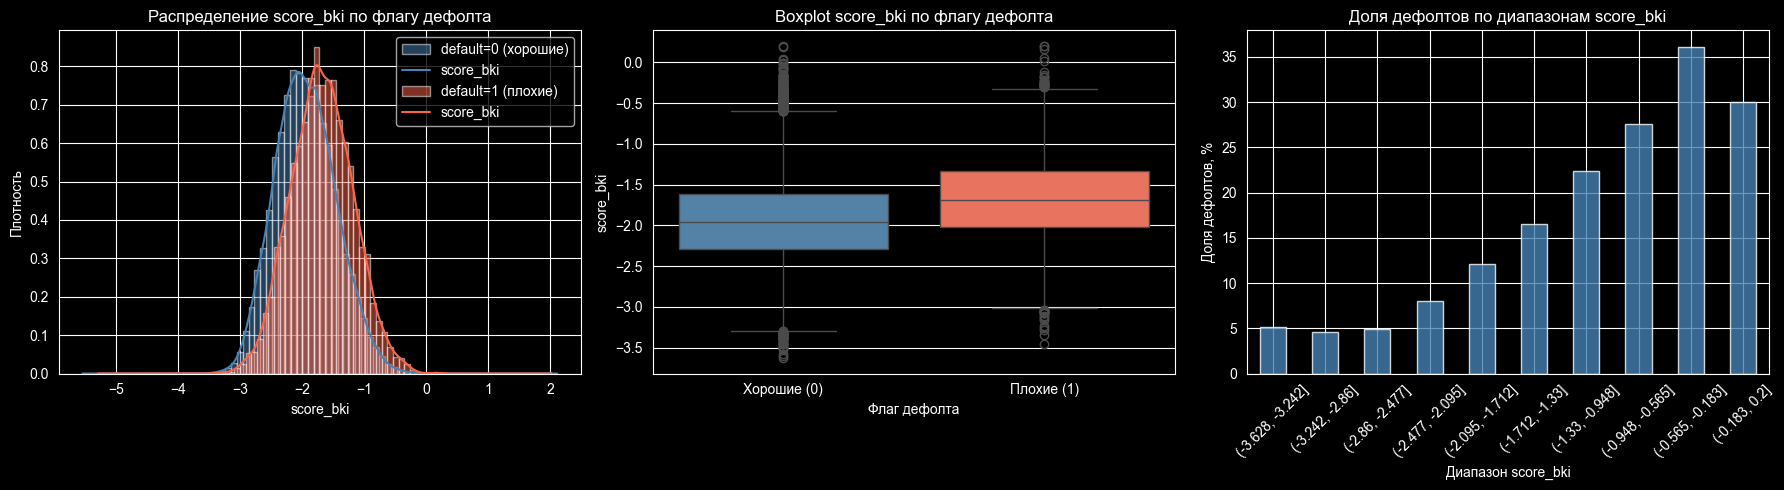


Критерий Манна-Уитни (H1: score_bki хороших < плохих):
  U = 212141152, p-value = 0.0000
  → score_bki хороших заёмщиков значимо меньше. Гипотеза ПОДТВЕРЖДАЕТСЯ.

Точечно-бисериальная корреляция (default ~ score_bki):
  r = 0.1754, p-value = 0.0000
  → Значимая прямая связь: выше score → больше дефолтов.


In [14]:
#5. score_bki напрямую взаимосвязан с default:
# чем он меньше, тем выше вероятность клиента выплатить кредит банку


score_good = df[df['default'] == False]['score_bki']
score_bad  = df[df['default'] == True]['score_bki']

# Описательные статистики
print("Статистики по score_bki:")
print(f"  default=0 (хорошие): среднее={score_good.mean():.4f}, медиана={score_good.median():.4f}")
print(f"  default=1 (плохие):  среднее={score_bad.mean():.4f}, медиана={score_bad.median():.4f}")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KDE + гистограмма
for label, data, color in [('default=0 (хорошие)', score_good, 'steelblue'),
                             ('default=1 (плохие)',  score_bad,  'tomato')]:
    axes[0].hist(data, bins=40, alpha=0.5, color=color, label=label, density=True)
    data.plot.kde(ax=axes[0], color=color)
axes[0].set_title('Распределение score_bki по флагу дефолта')
axes[0].set_xlabel('score_bki')
axes[0].set_ylabel('Плотность')
axes[0].legend()

# Boxplot
df_plot = df[['score_bki', 'default']].copy()
df_plot['default_label'] = df_plot['default'].map({False: 'Хорошие (0)', True: 'Плохие (1)'})
sns.boxplot(data=df_plot, x='default_label', y='score_bki',
            palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Boxplot score_bki по флагу дефолта')
axes[1].set_xlabel('Флаг дефолта')
axes[1].set_ylabel('score_bki')

# Средний score_bki по бинам — посмотрим тренд
df['default_int'] = df['default'].astype(int)
score_bins = pd.cut(df['score_bki'], bins=10)
default_by_score = df.groupby(score_bins, observed=True)['default_int'].mean() * 100
default_by_score.plot(kind='bar', color='steelblue', alpha=0.8, ax=axes[2])
axes[2].set_title('Доля дефолтов по диапазонам score_bki')
axes[2].set_xlabel('Диапазон score_bki')
axes[2].set_ylabel('Доля дефолтов, %')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Тест 1: Манна-Уитни (score_bki хороших < плохих, т.к. меньше score → лучше)
# По гипотезе: у хороших заёмщиков score_bki МЕНЬШЕ → alternative='less'
stat, p_value = stats.mannwhitneyu(score_good, score_bad, alternative='less')
print(f"\nКритерий Манна-Уитни (H1: score_bki хороших < плохих):")
print(f"  U = {stat:.0f}, p-value = {p_value:.4f}")
if p_value < 0.01:
    print(f"  → score_bki хороших заёмщиков значимо меньше. Гипотеза ПОДТВЕРЖДАЕТСЯ.")
else:
    print(f"  → Гипотеза НЕ подтверждается.")

# Тест 2: Точечно-бисериальная корреляция
corr, p_corr = stats.pointbiserialr(df['default_int'], df['score_bki'])
print(f"\nТочечно-бисериальная корреляция (default ~ score_bki):")
print(f"  r = {corr:.4f}, p-value = {p_corr:.4f}")
if p_corr < 0.01:
    direction = "прямая" if corr > 0 else "обратная"
    print(f"  → Значимая {direction} связь: {'выше score → больше дефолтов' if corr > 0 else 'ниже score → меньше дефолтов'}.")



Наличие авто (car):
       Всего  Дефолтов  Доля дефолтов, %
car                                     
False  49832      6825             13.70
True   23967      2547             10.63

Иномарка (car_type):
          Всего  Дефолтов  Доля дефолтов, %
car_type                                   
False     59791      8147             13.63
True      14008      1225              8.75


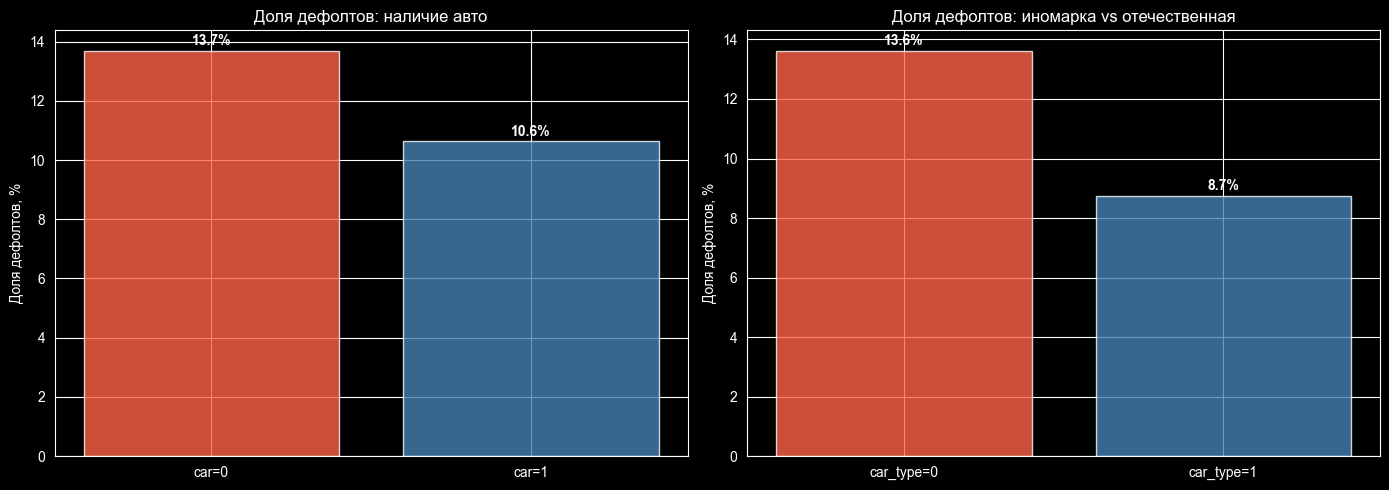


Хи-квадрат (дефолт ~ car):
  χ² = 137.20, df = 1, p-value = 0.0000
  → Связь значима. Доля дефолтов: без авто=13.7%, с авто=10.6%.
  → Наличие авто снижает риск дефолта.

Хи-квадрат (дефолт ~ car_type):
  χ² = 243.42, df = 1, p-value = 0.0000
  → Связь значима. Доля дефолтов: без авто=13.6%, с авто=8.7%.
  → Наличие авто снижает риск дефолта.


In [15]:
#6. Наличие авто влияет на вероятность возврата кредита

#  Описательные статистики
for col, label in [('car', 'Наличие авто (car)'), ('car_type', 'Иномарка (car_type)')]:
    print(f"\n{label}:")
    tbl = df.groupby(col)['default'].agg(['mean', 'sum', 'count'])
    tbl.columns = ['Доля дефолтов', 'Дефолтов', 'Всего']
    tbl['Доля дефолтов, %'] = (tbl['Доля дефолтов'] * 100).round(2)
    print(tbl[['Всего', 'Дефолтов', 'Доля дефолтов, %']])

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'car',      'Доля дефолтов: наличие авто'),
    (axes[1], 'car_type', 'Доля дефолтов: иномарка vs отечественная'),
]:
    rates = df.groupby(col)['default'].mean() * 100
    colors = ['tomato' if not k else 'steelblue' for k in rates.index]
    bars = ax.bar([f'{col}=0', f'{col}=1'], rates.values, color=colors, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('Доля дефолтов, %')
    for bar, v in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.2, f'{v:.1f}%',
                ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#  Статистический тест: хи-квадрат
for col, label in [('car', 'car'), ('car_type', 'car_type')]:
    ct = pd.crosstab(df[col], df['default'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"\nХи-квадрат (дефолт ~ {label}):")
    print(f"  χ² = {chi2:.2f}, df = {dof}, p-value = {p:.4f}")
    r0 = df[df[col] == False]['default'].mean() * 100
    r1 = df[df[col] == True]['default'].mean() * 100
    if p < 0.01:
        print(f"  → Связь значима. Доля дефолтов: без авто={r0:.1f}%, с авто={r1:.1f}%.")
        print(f"  → {'Наличие авто снижает' if r1 < r0 else 'Наличие авто повышает'} риск дефолта.")
    else:
        print(f"  → Значимой связи не обнаружено. Гипотеза НЕ подтверждается.")


Доход и дефолт по рейтингу региона:
               Всего  Доход_среднее  Доход_медиана  Доля_дефолтов, %
region_rating                                                       
20               206        31213.0        23000.0              20.0
30               300        29108.3        21500.0              20.0
40             12027        33620.8        25000.0              20.0
50             27523        35024.4        25000.0              10.0
60             16075        37535.5        30000.0              10.0
70              6199        55842.0        42000.0              10.0
80             11469        61040.9        47000.0              10.0


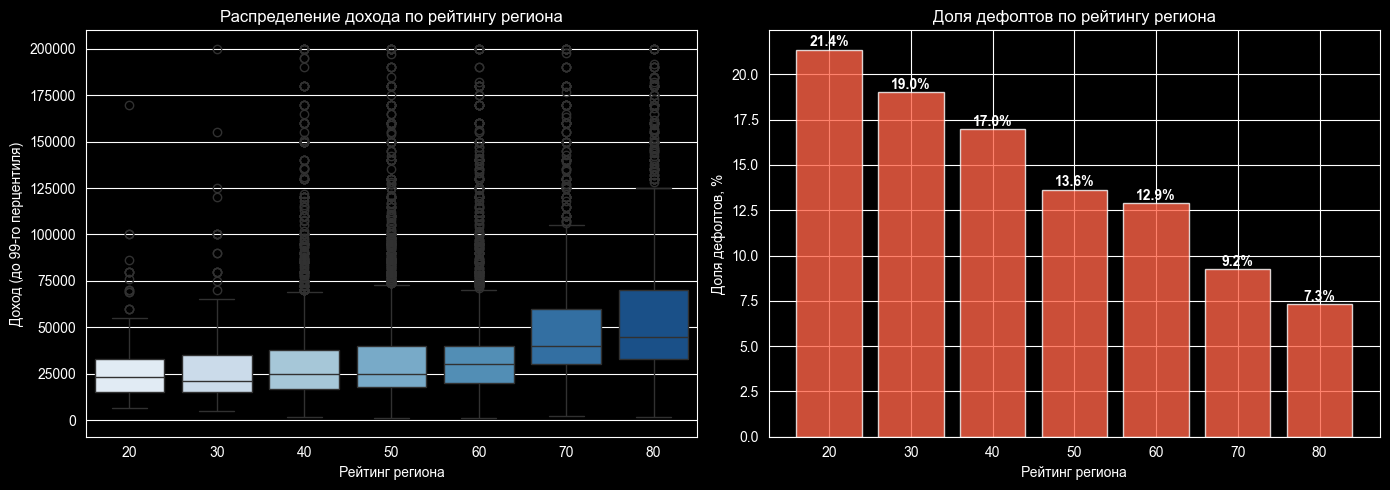


Краскела-Уоллис (доход ~ регион):
  H = 9741.14, p-value = 0.0000
  → Доход значимо различается между регионами.

Хи-квадрат (дефолт ~ регион):
  χ² = 610.46, df = 6, p-value = 0.0000
  → Рейтинг региона статистически значимо связан с вероятностью дефолта.

Корреляция Спирмена (region_rating ~ income):
  ρ = 0.3140, p-value = 0.0000
  → Значимая прямая связь: выше рейтинг → выше доход.


In [16]:
#7. Рейтинг региона влияет на размер зарплаты, что также может повлиять на возврат кредита

regions = sorted(df['region_rating'].unique())

# Описательные статистики
print("Доход и дефолт по рейтингу региона:")
summary = df.groupby('region_rating').agg(
    Всего=('income', 'count'),
    Доход_среднее=('income', 'mean'),
    Доход_медиана=('income', 'median'),
    Доля_дефолтов=('default', 'mean')
).round(1)
summary['Доля_дефолтов, %'] = (summary['Доля_дефолтов'] * 100).round(2)
print(summary[['Всего', 'Доход_среднее', 'Доход_медиана', 'Доля_дефолтов, %']])

#  Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot дохода по региону (обрезаем выбросы)
cap = df['income'].quantile(0.99)
sns.boxplot(data=df[df['income'] <= cap], x='region_rating', y='income',
            order=regions, palette='Blues', ax=axes[0])
axes[0].set_title('Распределение дохода по рейтингу региона')
axes[0].set_xlabel('Рейтинг региона')
axes[0].set_ylabel('Доход (до 99-го перцентиля)')

# Доля дефолтов по региону
default_by_region = df.groupby('region_rating')['default'].mean() * 100
axes[1].bar([str(r) for r in default_by_region.index], default_by_region.values,
            color='tomato', alpha=0.8)
axes[1].set_title('Доля дефолтов по рейтингу региона')
axes[1].set_xlabel('Рейтинг региона')
axes[1].set_ylabel('Доля дефолтов, %')
for i, v in enumerate(default_by_region.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Тест 1: Краскела-Уоллиса — доход ~ регион
groups_income = [df[df['region_rating'] == r]['income'].values for r in regions]
stat_kw, p_kw = stats.kruskal(*groups_income)
print(f"\nКраскела-Уоллис (доход ~ регион):")
print(f"  H = {stat_kw:.2f}, p-value = {p_kw:.4f}")
if p_kw < 0.01:
    print("  → Доход значимо различается между регионами.")
else:
    print("  → Значимых различий дохода между регионами не обнаружено.")

#  Тест 2: Хи-квадрат — дефолт ~ регион
ct = pd.crosstab(df['region_rating'], df['default'])
chi2, p_chi2, dof, _ = stats.chi2_contingency(ct)
print(f"\nХи-квадрат (дефолт ~ регион):")
print(f"  χ² = {chi2:.2f}, df = {dof}, p-value = {p_chi2:.4f}")
if p_chi2 < 0.01:
    print("  → Рейтинг региона статистически значимо связан с вероятностью дефолта.")
else:
    print("  → Значимой связи между регионом и дефолтом не обнаружено.")

#  Корреляция Спирмена: region_rating ~ income
corr_s, p_s = stats.spearmanr(df['region_rating'], df['income'])
print(f"\nКорреляция Спирмена (region_rating ~ income):")
print(f"  ρ = {corr_s:.4f}, p-value = {p_s:.4f}")
if p_s < 0.01:
    print(f"  → Значимая {'прямая' if corr_s > 0 else 'обратная'} связь: "
          f"{'выше рейтинг → выше доход' if corr_s > 0 else 'выше рейтинг → ниже доход'}.")
else:
    print("  → Значимой связи между рейтингом региона и доходом не обнаружено.")
